In [1]:
pip install rioxarray

Note: you may need to restart the kernel to use updated packages.


# **VEGETATION INDICES**

Membaca file mask sawah lokal...
Mengambil citra Sentinel-2 terbaru (Juli 2026)...

=== Memproses & mengekspor GeoJSON per indeks ===
Mengunduh dan menyatukan tile untuk: sawah_evi.tif...
   -> EVI: GeoJSON tersimpan (5 fitur kelas, 17,236 KB): ../../data/processed\Klasifikasi_EVI_2026-07-26.geojson
Mengunduh dan menyatukan tile untuk: sawah_msavi.tif...
   -> MSAVI: GeoJSON tersimpan (5 fitur kelas, 16,991 KB): ../../data/processed\Klasifikasi_MSAVI_2026-07-26.geojson
Mengunduh dan menyatukan tile untuk: sawah_rdvi.tif...
   -> RDVI: GeoJSON tersimpan (5 fitur kelas, 16,666 KB): ../../data/processed\Klasifikasi_RDVI_2026-07-26.geojson
Mengunduh dan menyatukan tile untuk: sawah_gndvi.tif...
   -> GNDVI: GeoJSON tersimpan (5 fitur kelas, 17,193 KB): ../../data/processed\Klasifikasi_GNDVI_2026-07-26.geojson
Mengunduh dan menyatukan tile untuk: sawah_ndre.tif...
   -> NDRE: GeoJSON tersimpan (5 fitur kelas, 17,828 KB): ../../data/processed\Klasifikasi_NDRE_2026-07-26.geojson
Mengunduh dan

## 📊 Pratinjau Hasil Analisis Indeks Vegetasi & Biofisik Sawah

**Tanggal Citra Utama:** 2026-07-26 | **Jumlah GeoJSON:** 7

### 📈 Time Series Indeks Spektral (halus, tersambung)

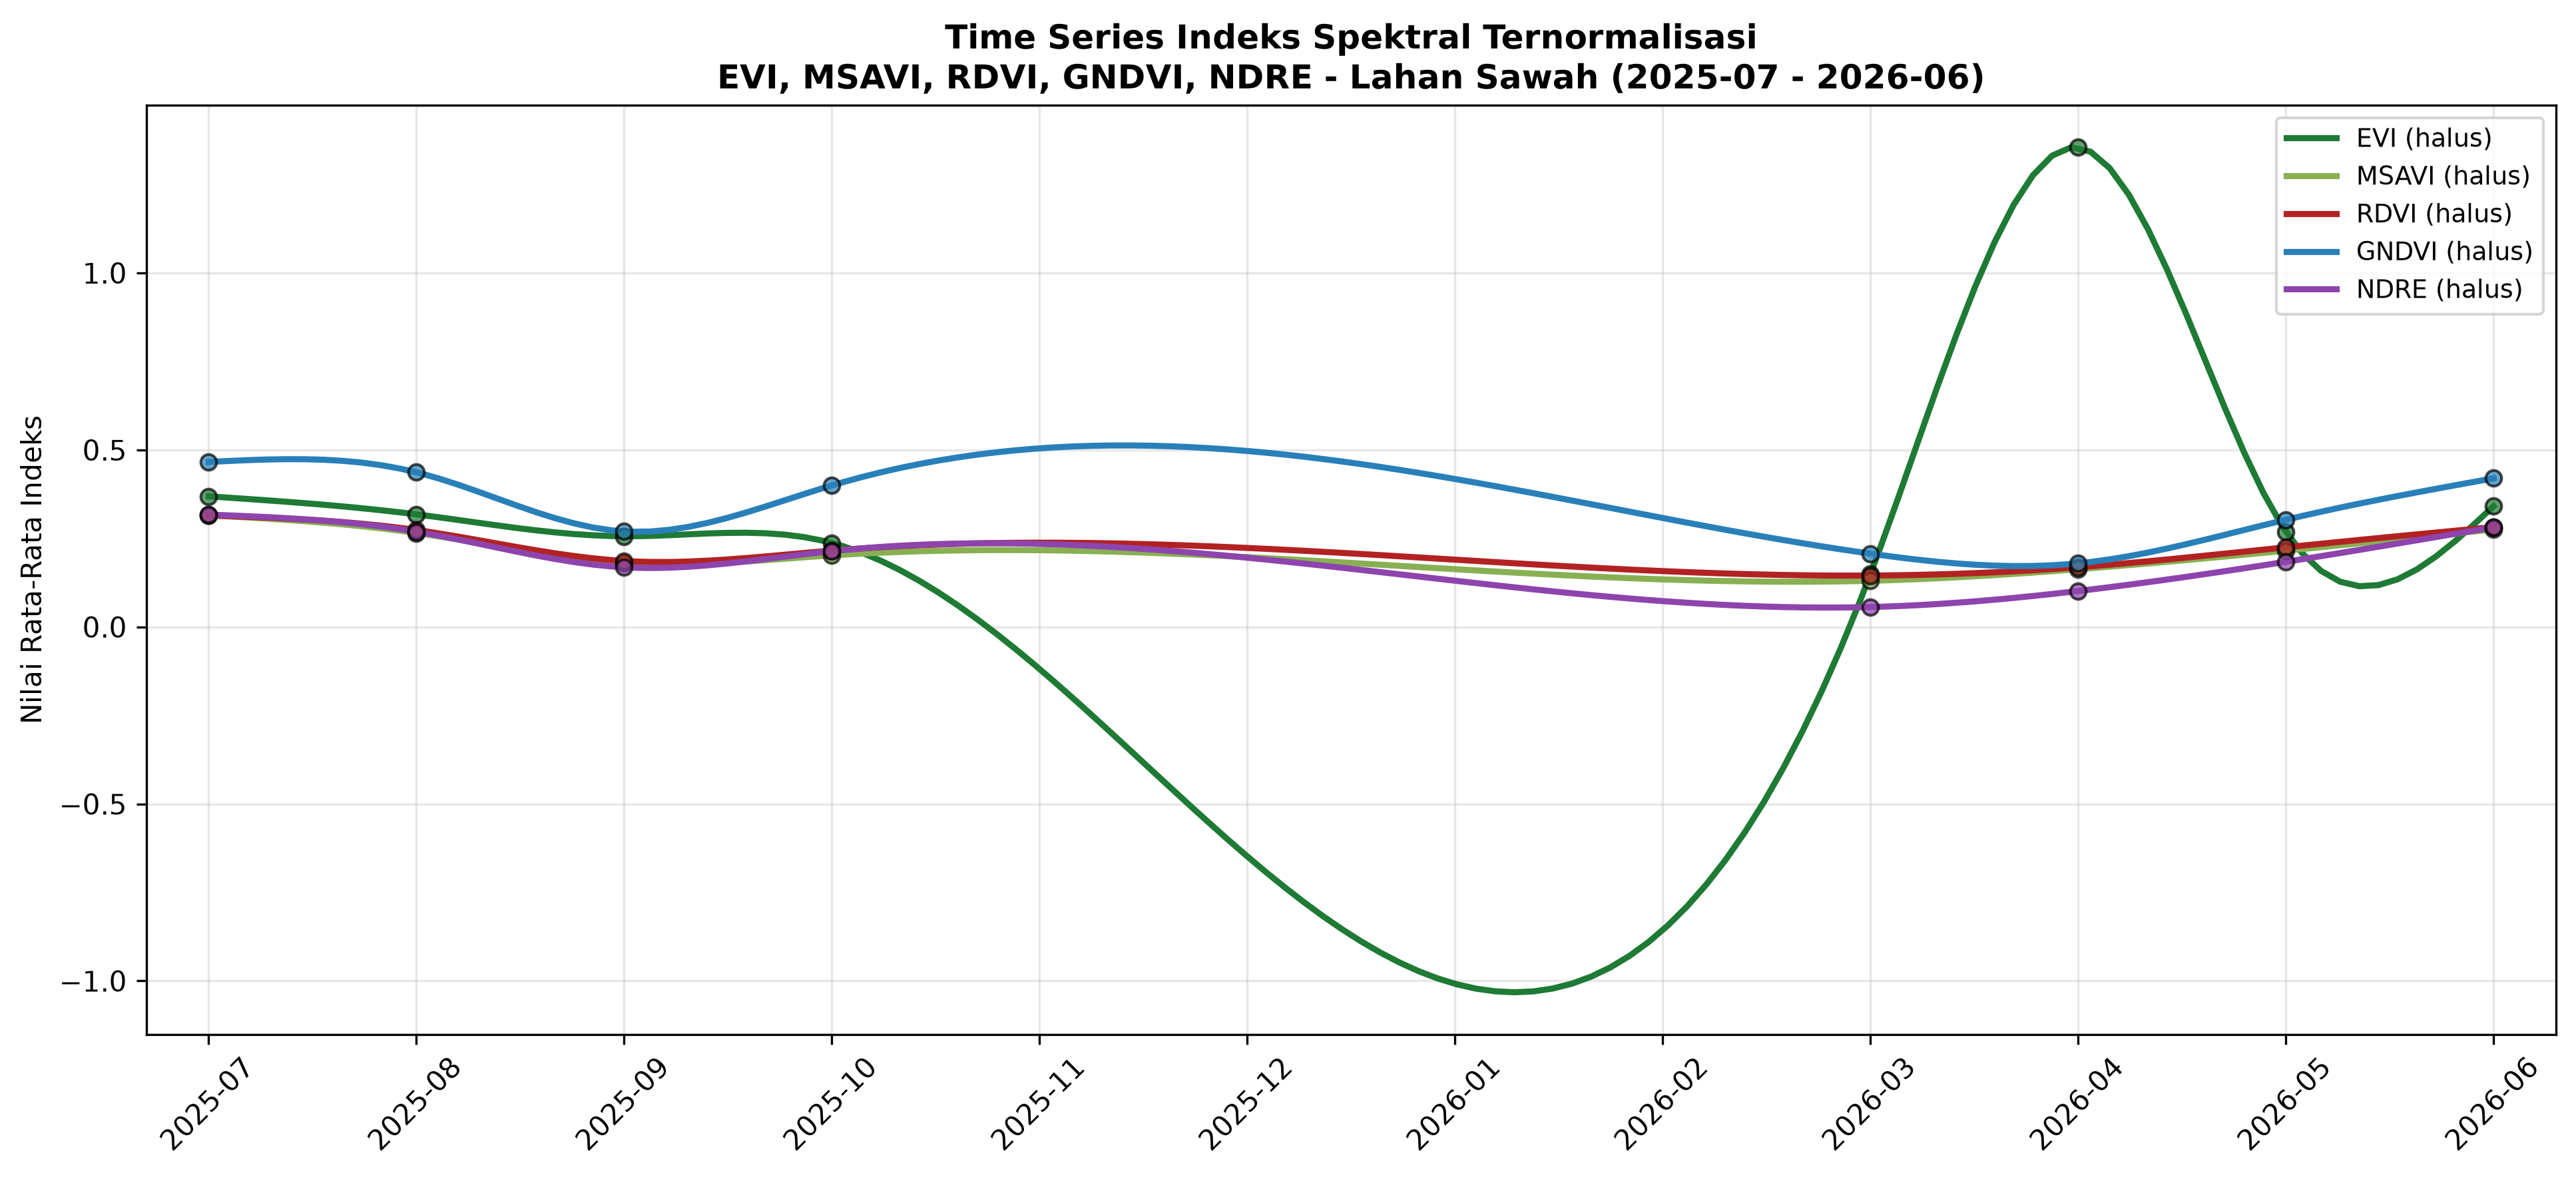

### 📈 Time Series Estimasi Biofisik: LAI vs AGB (halus, tersambung)

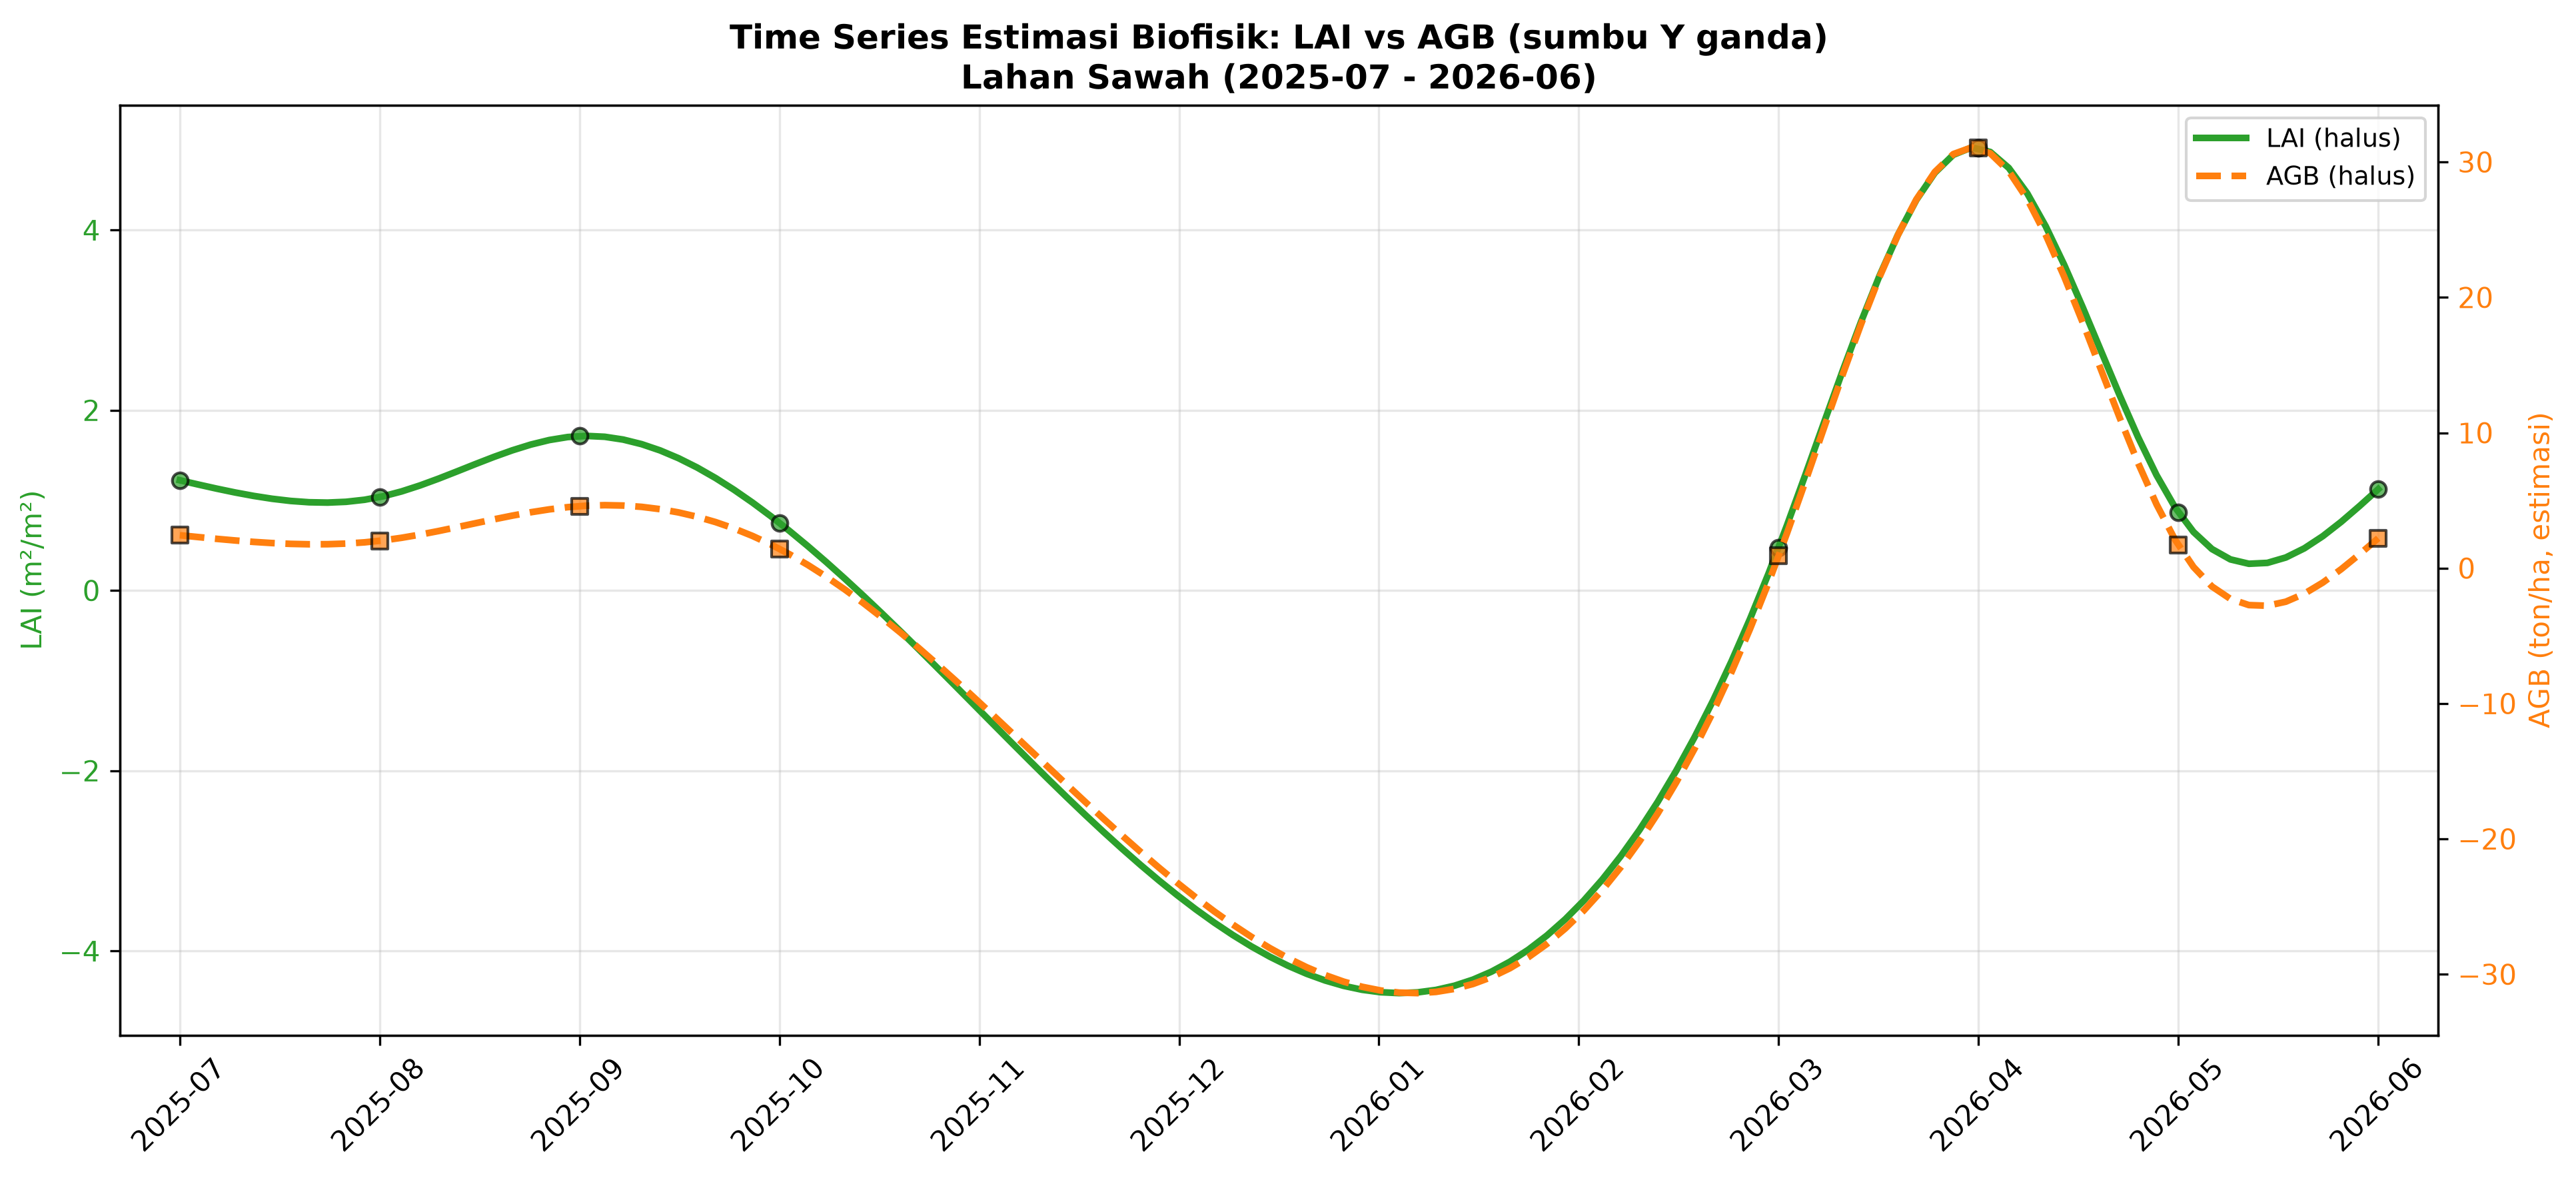

### 🗺️ Pratinjau GeoJSON per Indeks (5 kelas kuantil: Sangat Rendah - Sangat Tinggi)

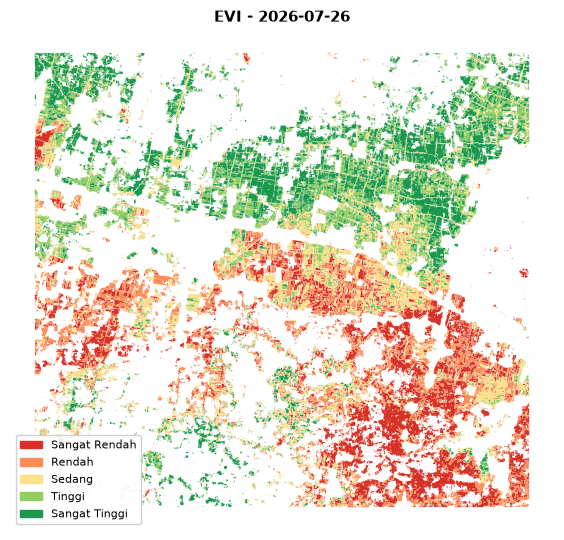

*File: `../../data/processed\Klasifikasi_EVI_2026-07-26.geojson`*

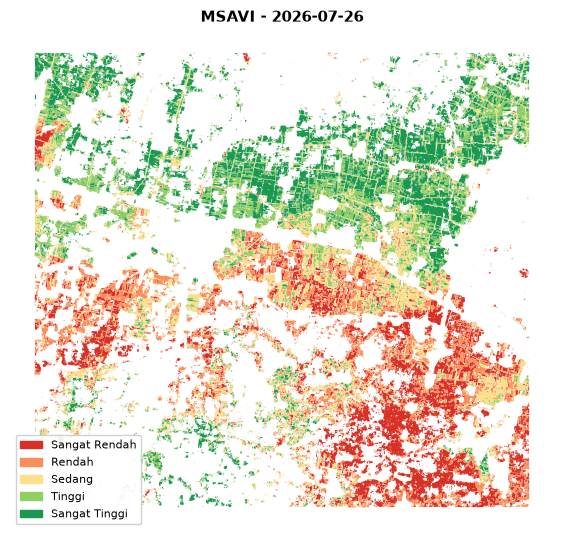

*File: `../../data/processed\Klasifikasi_MSAVI_2026-07-26.geojson`*

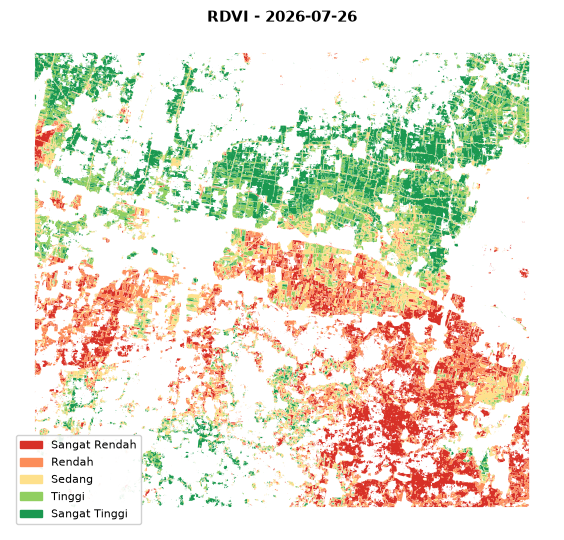

*File: `../../data/processed\Klasifikasi_RDVI_2026-07-26.geojson`*

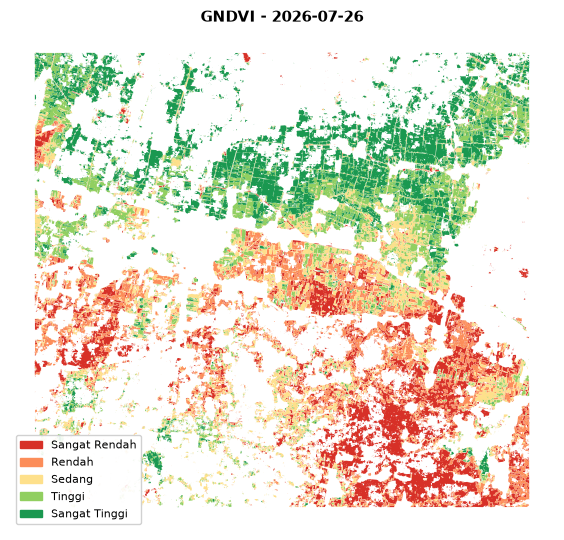

*File: `../../data/processed\Klasifikasi_GNDVI_2026-07-26.geojson`*

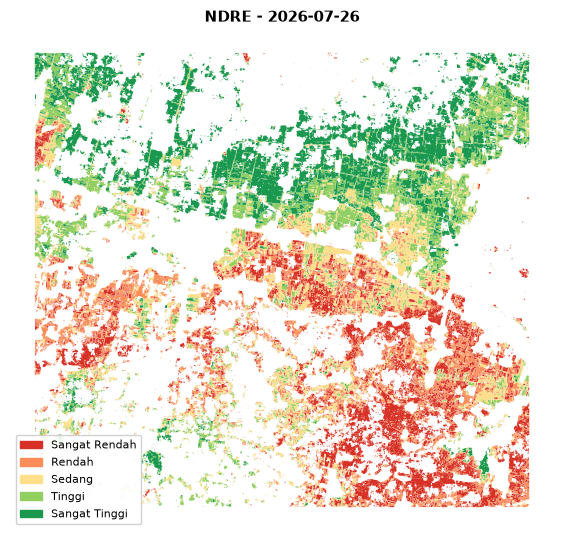

*File: `../../data/processed\Klasifikasi_NDRE_2026-07-26.geojson`*

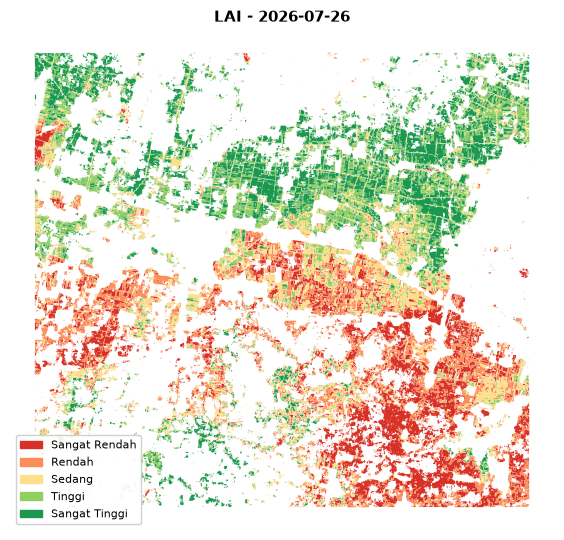

*File: `../../data/processed\Klasifikasi_LAI_2026-07-26.geojson`*

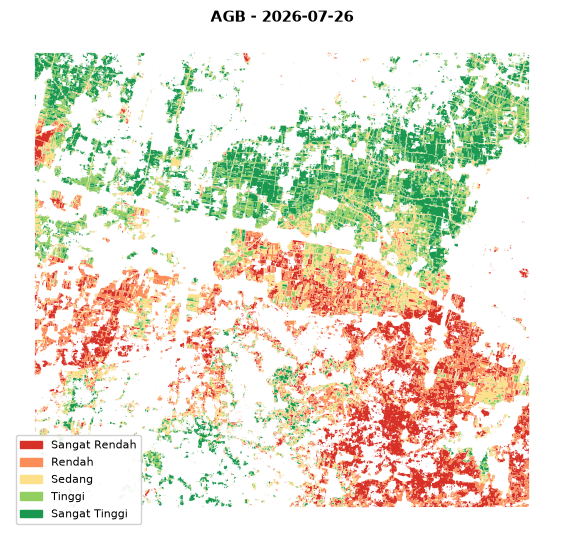

*File: `../../data/processed\Klasifikasi_AGB_2026-07-26.geojson`*


=== SEMUA PROSES DAN PRATINJAU SELESAI ===


In [2]:
"""
================================================================================
ANALISIS INDEKS VEGETASI & ESTIMASI BIOFISIK LAHAN SAWAH (GEE)
REVISI: HANYA GEOJSON + PNG TIME SERIES, GRAFIK DIHALUSKAN & DIPISAH,
        + PRATINJAU HASIL DI AKHIR UNTUK REVIEW
================================================================================
Tiga masukan yang diterapkan di atas skrip asli:

  1. OUTPUT DIPANGKAS: peta kartografis PNG per-indeks (imshow satu-satu) DAN
     laporan DOCX DIHAPUS - keduanya bukan yg diminta. Sbg gantinya, tiap
     indeks (5 indeks spektral: EVI, MSAVI, RDVI, GNDVI, NDRE; 2 estimasi
     biofisik: LAI, AGB) diekspor sbg GEOJSON. Karena nilai indeks ini
     KONTINU (bukan kategorikal spt fase tanam), raster diklasifikasi dulu
     ke 5 kelas kuantil (persentil 2-98 piksel sawah valid, dibagi rata jd
     5 bin: Sangat Rendah..Sangat Tinggi) sblm dipoligonisasi & di-dissolve
     per kelas (pola sama dgn modul fase tanam padi: 1 kelas = 1 fitur = 1
     legenda, ringkas utk WebGIS). Tiap fitur diberi properti kelas, label,
     rentang_nilai (agar WebGIS bisa tampilkan skala aslinya), luas_ha.
     Output akhir per run: 7 GeoJSON (satu per indeks) + 2 PNG time series.

  2. TIME SERIES DIHALUSKAN & DIPISAH. Versi asli memakai matplotlib.plot
     apa adanya (garis putus tiap kali ada bulan NaN krn tutupan awan, dan
     kedua kelompok indeks digabung dlm 1 figure 2-panel). Kini dipakai
     spline kubik (fallback linear bila titik valid <4, pola sama spt modul
     fase tanam padi) yg HANYA di-fit pd titik valid lalu dievaluasi di
     seluruh rentang bulan - shg kurva SELALU tersambung mulus walau ada
     bulan tanpa citra bersih, dan lebih mudah dibaca. Dipisah jd 2 file PNG
     terpisah (bukan 1 figure 2-panel): "Grafik_TimeSeries_Indeks_Spektral.png"
     (EVI/MSAVI/RDVI/GNDVI/NDRE, skala sebanding) dan
     "Grafik_TimeSeries_Biofisik.png" (LAI vs AGB, sumbu Y ganda krn beda
     satuan) - titik data asli (bulan bertitik) tetap ditampilkan sbg
     scatter di atas kurva halus utk transparansi drmn kurva berasal.

  3. PRATINJAU HASIL DI AKHIR. Ditambahkan bagian akhir yg menampilkan
     LANGSUNG di notebook: kedua PNG time series, DAN peta pratinjau tiap
     GeoJSON (di-render dari GeoDataFrame yg baru disimpan, diwarnai per
     kelas + legenda) - shg seluruh hasil bisa direview tanpa perlu
     membuka file satu-satu.
================================================================================
"""

import ee
import os
import datetime
import urllib.request
import numpy as np
import rasterio
from rasterio.merge import merge
from rasterio.features import shapes as rio_shapes
import rioxarray
import xarray as xr
import geopandas as gpd
from shapely.geometry import shape as shapely_shape
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from scipy.interpolate import CubicSpline, interp1d
from IPython.display import Image, display, Markdown

# ==========================================
# 1. INISIALISASI & KONFIGURASI AWAL
# ==========================================
ee.Authenticate() # Jalankan jika belum autentikasi
ee.Initialize(project='poetic-emblem-487109-t6')

RAW_DIR = "../../data/raw"
PROCESSED_DIR = "../../data/processed"
FIGURES_DIR = "../../results/figures/module_3"
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

file_mask_sawah = os.path.join(PROCESSED_DIR, 'Klasifikasi_Sawah.tif')
MODULE_DIR = os.path.join(PROCESSED_DIR, "module_3")
os.makedirs(MODULE_DIR, exist_ok=True)
FOLDER_CACHE = os.path.join(MODULE_DIR, "cache_indeks_vegetasi")
os.makedirs(FOLDER_CACHE, exist_ok=True)

NODATA = 255

# --- Indeks dikelompokkan berdasarkan skala nilainya ---
VI_LIST_NORMALIZED = ['EVI', 'MSAVI', 'RDVI', 'GNDVI', 'NDRE']
VI_LIST_DERIVED = ['LAI', 'AGB']
VI_LIST = VI_LIST_NORMALIZED + VI_LIST_DERIVED

# --- Klasifikasi kuantil utk ekspor GeoJSON (poin #1) ---
N_KELAS_GEOJSON = 5
LABEL_KELAS_KUANTIL = ["Sangat Rendah", "Rendah", "Sedang", "Tinggi", "Sangat Tinggi"]
WARNA_KELAS_KUANTIL = ["#D73027", "#FC8D59", "#FEE08B", "#91CF60", "#1A9850"]

print("Membaca file mask sawah lokal...")
mask_daerah = rioxarray.open_rasterio(file_mask_sawah)
template_2d = mask_daerah.squeeze()
bounds = mask_daerah.rio.bounds()  # (minx, miny, maxx, maxy)

mask_wgs84 = mask_daerah.rio.reproject("EPSG:4326")
wgs84_bounds = mask_wgs84.rio.bounds()
aoi_ee = ee.Geometry.Rectangle([wgs84_bounds[0], wgs84_bounds[1], wgs84_bounds[2], wgs84_bounds[3]])
sawah_mask_2d = (template_2d == 1)

# ==========================================
# 2. FUNGSI BANTUAN TILING & DOWNLOAD GEE
# ==========================================
def unduh_raster_ee_per_band(ee_image, aoi_geometry, nama_file_output, scale=10):
    """Unduh 1 band dgn tiling 2x2 (menghindari batas ukuran getDownloadURL GEE), lalu mosaik lokal."""
    print(f"Mengunduh dan menyatukan tile untuk: {nama_file_output}...")
    bounds_geom = aoi_geometry.bounds().getInfo()['coordinates'][0]
    minx, miny = min([p[0] for p in bounds_geom]), min([p[1] for p in bounds_geom])
    maxx, maxy = max([p[0] for p in bounds_geom]), max([p[1] for p in bounds_geom])

    n_split = 2
    x_steps = np.linspace(minx, maxx, n_split + 1)
    y_steps = np.linspace(miny, maxy, n_split + 1)
    temp_files = []

    for i in range(n_split):
        for j in range(n_split):
            sub_box = ee.Geometry.Rectangle([x_steps[i], y_steps[j], x_steps[i+1], y_steps[j+1]])
            try:
                url = ee_image.getDownloadURL({
                    'scale': scale,
                    'crs': 'EPSG:4326',
                    'region': sub_box,
                    'format': 'GEO_TIFF'
                })
                sub_file = os.path.join(FOLDER_CACHE, f"temp_tile_{i}_{j}_{nama_file_output}")
                urllib.request.urlretrieve(url, sub_file)
                temp_files.append(sub_file)
            except Exception as e:
                pass

    if not temp_files:
        raise RuntimeError(f"Gagal mengunduh {nama_file_output}")

    src_files_to_mosaic = [rasterio.open(f) for f in temp_files]
    mosaic, out_trans = merge(src_files_to_mosaic)
    meta = src_files_to_mosaic[0].meta.copy()
    for src in src_files_to_mosaic:
        src.close()

    meta.update({"height": mosaic.shape[1], "width": mosaic.shape[2], "transform": out_trans})

    path_out = os.path.join(FOLDER_CACHE, nama_file_output)
    with rasterio.open(path_out, "w", **meta) as dest:
        dest.write(mosaic)

    for f in temp_files:
        if os.path.exists(f):
            os.remove(f)

    da = rioxarray.open_rasterio(path_out).rio.reproject_match(mask_daerah)
    return da


def bersihkan_outlier(arr, batas_bawah, batas_atas):
    """Menggantikan piksel di luar rentang wajar dgn NaN (nilai tdk fisikal)."""
    arr_clean = np.where((arr < batas_bawah) | (arr > batas_atas), np.nan, arr)
    return arr_clean


# ==========================================
# 2B. KLASIFIKASI KUANTIL + EKSPOR GEOJSON (poin #1)
# ==========================================
def klasifikasikan_dan_simpan_geojson(arr, transform, crs, nama_index, path_out,
                                       n_kelas=N_KELAS_GEOJSON, toleransi_simplify_m=15):
    """
    Klasifikasi raster indeks KONTINU jd n_kelas kategori kuantil (persentil
    2-98 piksel valid, dibagi rata) -> poligonisasi per piksel bertetangga
    senilai sama (4-connectivity) -> DISSOLVE per kelas -> simplify ringan
    (dlm meter, sblm reproject) -> reproject EPSG:4326 -> tulis GeoJSON.
    Properti tiap fitur: kelas, label, rentang_nilai (skala asli indeks),
    indeks (nama), luas_ha.
    """
    valid = arr[~np.isnan(arr)]
    if valid.size == 0:
        print(f"   [Peringatan] {nama_index}: tidak ada piksel valid, GeoJSON dilewati.")
        return None

    batas = np.nanpercentile(valid, np.linspace(2, 98, n_kelas + 1))
    batas_interior = batas[1:-1]

    kelas_u8 = np.full(arr.shape, NODATA, dtype=np.uint8)
    mask_valid = ~np.isnan(arr)
    kelas_u8[mask_valid] = np.digitize(arr[mask_valid], batas_interior, right=False).astype(np.uint8)

    records = [
        {"kelas": int(val), "geometry": shapely_shape(geom)}
        for geom, val in rio_shapes(kelas_u8, mask=(kelas_u8 != NODATA), transform=transform, connectivity=4)
    ]
    if not records:
        print(f"   [Peringatan] {nama_index}: tidak ada fitur terpoligonisasi, GeoJSON dilewati.")
        return None

    gdf = gpd.GeoDataFrame(records, crs=crs)
    gdf = gdf.dissolve(by="kelas", as_index=False)

    if toleransi_simplify_m and toleransi_simplify_m > 0:
        gdf["geometry"] = gdf["geometry"].simplify(toleransi_simplify_m, preserve_topology=True)

    luas_m2 = gdf.geometry.area
    gdf["luas_ha"] = (luas_m2 / 10000).round(2)
    gdf["label"] = gdf["kelas"].apply(lambda k: LABEL_KELAS_KUANTIL[k] if k < len(LABEL_KELAS_KUANTIL) else f"Kelas {k}")

    def rentang_teks(k):
        lo = batas[k] if k > 0 else valid.min()
        hi = batas[k + 1] if k < n_kelas - 1 else valid.max()
        return f"{lo:.3f} - {hi:.3f}"
    gdf["rentang_nilai"] = gdf["kelas"].apply(rentang_teks)
    gdf["indeks"] = nama_index

    gdf = gdf.to_crs("EPSG:4326")
    gdf.to_file(path_out, driver="GeoJSON")

    ukuran_kb = os.path.getsize(path_out) / 1024
    print(f"   -> {nama_index}: GeoJSON tersimpan ({len(gdf)} fitur kelas, {ukuran_kb:,.0f} KB): {path_out}")
    return gdf


# ==========================================
# 3. PENGAMBILAN CITRA TERBARU & PERHITUNGAN INDEKS
# ==========================================
print("Mengambil citra Sentinel-2 terbaru (Juli 2026)...")
s2_juli2026 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
    .filterBounds(aoi_ee) \
    .filterDate('2026-07-01', '2026-07-31') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .sort('system:time_start', False) \
    .first() \
    .clip(aoi_ee)

tanggal_citra = ee.Date(s2_juli2026.get('system:time_start')).format('YYYY-MM-dd').getInfo()

img_scaled = s2_juli2026.multiply(0.0001)
dict_b = {
    'N': img_scaled.select('B8'),    # NIR
    'R': img_scaled.select('B4'),    # Red
    'G': img_scaled.select('B3'),    # Green
    'B': img_scaled.select('B2'),    # Blue
    'RE': img_scaled.select('B5'),   # Red Edge (untuk NDRE)
}

EPS = 1e-6  # epsilon anti divide-by-near-zero

# --- Indeks spektral dasar ---
evi = img_scaled.expression(
    '2.5 * (N - R) / (N + 6 * R - 7.5 * B + 1 + EPS)', {**dict_b, 'EPS': EPS}
).rename('EVI')

msavi = img_scaled.expression(
    '(2 * N + 1 - sqrt((2 * N + 1) * (2 * N + 1) - 8 * (N - R))) / 2', dict_b
).rename('MSAVI')

rdvi = img_scaled.expression('(N - R) / sqrt(N + R)', dict_b).rename('RDVI')

gndvi = img_scaled.normalizedDifference(['B8', 'B3']).rename('GNDVI')
ndre = img_scaled.normalizedDifference(['B8', 'B5']).rename('NDRE')

# --- Indeks turunan biofisik: LAI dan AGB (estimasi empiris berbasis EVI, ILUSTRATIF) ---
lai = evi.expression('3.618 * EVI - 0.118', {'EVI': evi}).rename('LAI').max(0)
agb = lai.expression('1.9 * pow(LAI, 1.1)', {'LAI': lai}).rename('AGB').max(0)

vi_images = {
    'EVI': evi, 'MSAVI': msavi, 'RDVI': rdvi, 'GNDVI': gndvi, 'NDRE': ndre,
    'LAI': lai, 'AGB': agb,
}

# --- Rentang wajar per indeks (utk bersihkan outlier sblm klasifikasi kuantil) ---
rentang_wajar = {
    'EVI': (-1, 1.5), 'MSAVI': (-1, 1), 'RDVI': (-1, 1),
    'GNDVI': (-1, 1), 'NDRE': (-1, 1),
    'LAI': (0, 10), 'AGB': (0, 40),
}

hasil_geojson = {}   # nama_vi -> (GeoDataFrame, path_file)

print("\n=== Memproses & mengekspor GeoJSON per indeks ===")
for nama_vi, img_ee in vi_images.items():
    tif_name = f"sawah_{nama_vi.lower()}.tif"
    da_raw = unduh_raster_ee_per_band(img_ee, aoi_ee, tif_name)

    arr_masked = da_raw.squeeze().where(sawah_mask_2d).values
    batas_bawah, batas_atas = rentang_wajar.get(nama_vi, (-1e9, 1e9))
    arr_masked = bersihkan_outlier(arr_masked, batas_bawah, batas_atas)

    path_geojson = os.path.join(MODULE_DIR, f"Klasifikasi_{nama_vi}_{tanggal_citra}.geojson")
    gdf = klasifikasikan_dan_simpan_geojson(
        arr_masked, mask_daerah.rio.transform(), mask_daerah.rio.crs, nama_vi, path_geojson
    )
    if gdf is not None:
        hasil_geojson[nama_vi] = (gdf, path_geojson)

# ==========================================
# 4. TIME SERIES 1 TAHUN (JULI 2025 - JUNI 2026) - DIKUMPULKAN
# ==========================================
print("\nMengekstrak data time series bulanan (Juli 2025 - Juni 2026)...")
bulan_list = []
ts_data = {vi: [] for vi in VI_LIST}

start_date = datetime.date(2025, 7, 1)
for i in range(12):
    y = start_date.year + (start_date.month - 1 + i) // 12
    m = (start_date.month - 1 + i) % 12 + 1
    m_str = f"{m:02d}"

    t_awal = f"{y}-{m_str}-01"
    t_akhir = f"{y+1}-01-01" if m == 12 else f"{y}-{m+1:02d}-01"

    label_bln = f"{y}-{m_str}"
    bulan_list.append(label_bln)

    monthly_col = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
        .filterBounds(aoi_ee) \
        .filterDate(t_awal, t_akhir) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))

    if monthly_col.size().getInfo() == 0:
        for vi in VI_LIST:
            ts_data[vi].append(np.nan)
        continue

    monthly_median = monthly_col.median().clip(aoi_ee)
    m_scaled = monthly_median.multiply(0.0001)
    m_dict = {
        'N': m_scaled.select('B8'), 'R': m_scaled.select('B4'),
        'G': m_scaled.select('B3'), 'B': m_scaled.select('B2'),
        'RE': m_scaled.select('B5'),
        'EPS': EPS,
    }

    m_evi = m_scaled.expression('2.5 * (N - R) / (N + 6 * R - 7.5 * B + 1 + EPS)', m_dict).rename('EVI')
    m_msavi = m_scaled.expression(
        '(2 * N + 1 - sqrt((2 * N + 1) * (2 * N + 1) - 8 * (N - R))) / 2', m_dict
    ).rename('MSAVI')
    m_lai = m_evi.expression('3.618 * EVI - 0.118', {'EVI': m_evi}).rename('LAI').max(0)
    m_agb = m_lai.expression('1.9 * pow(LAI, 1.1)', {'LAI': m_lai}).rename('AGB').max(0)

    m_indices = ee.Image.cat([
        m_evi,
        m_msavi,
        m_scaled.expression('(N - R) / sqrt(N + R)', m_dict).rename('RDVI'),
        m_scaled.normalizedDifference(['B8', 'B3']).rename('GNDVI'),
        m_scaled.normalizedDifference(['B8', 'B5']).rename('NDRE'),
        m_lai,
        m_agb,
    ])

    mean_dict = m_indices.reduceRegion(reducer=ee.Reducer.mean(), geometry=aoi_ee, scale=30, maxPixels=1e9).getInfo()
    for vi in VI_LIST:
        val = mean_dict.get(vi, np.nan)
        if val is not None and vi in rentang_wajar:
            lo, hi = rentang_wajar[vi]
            if val < lo or val > hi:
                val = np.nan
        ts_data[vi].append(val if val is not None else np.nan)

# ==========================================
# 5. GRAFIK TIME SERIES - DIHALUSKAN & DIPISAH (poin #2)
# ==========================================
def haluskan_time_series(nilai, titik_per_bulan=10):
    """Spline kubik pd titik valid sj (fallback linear bila valid <4) -> kurva selalu tersambung mulus."""
    nilai = np.asarray(nilai, dtype=float)
    n = len(nilai)
    x = np.arange(n)
    idx_valid = ~np.isnan(nilai)
    if idx_valid.sum() < 2:
        return None, None
    if idx_valid.sum() < 4:
        f = interp1d(x[idx_valid], nilai[idx_valid], kind="linear", fill_value="extrapolate")
    else:
        f = CubicSpline(x[idx_valid], nilai[idx_valid], bc_type="natural")
    x_halus = np.linspace(0, n - 1, n * titik_per_bulan)
    return x_halus, f(x_halus)


print("\nMembuat grafik time series (halus, terpisah spektral vs biofisik)...")

WARNA_VI = {"EVI": "#1E7A34", "MSAVI": "#88B053", "RDVI": "#B22222", "GNDVI": "#2980B9", "NDRE": "#8E44AD"}

# --- 5A. Indeks spektral ternormalisasi (skala sebanding, 1 sumbu Y) ---
fig, ax = plt.subplots(figsize=(13, 6))
for vi in VI_LIST_NORMALIZED:
    x_halus, y_halus = haluskan_time_series(ts_data[vi])
    warna = WARNA_VI.get(vi, None)
    if x_halus is not None:
        ax.plot(x_halus, y_halus, lw=2.2, color=warna, label=f"{vi} (halus)")
    ax.scatter(range(len(ts_data[vi])), ts_data[vi], s=32, color=warna, zorder=5, edgecolor="black", alpha=0.7)
ax.set_xticks(range(len(bulan_list))); ax.set_xticklabels(bulan_list, rotation=45)
ax.set_xlim(-0.3, len(bulan_list) - 0.7)
ax.set_ylabel("Nilai Rata-Rata Indeks")
ax.set_title(f"Time Series Indeks Spektral Ternormalisasi\nEVI, MSAVI, RDVI, GNDVI, NDRE - Lahan Sawah "
             f"({bulan_list[0]} - {bulan_list[-1]})", fontsize=12, fontweight="bold")
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
nama_grafik_spektral = os.path.join(FIGURES_DIR, "Grafik_TimeSeries_Indeks_Spektral.png")
plt.savefig(nama_grafik_spektral, dpi=300, bbox_inches="tight")
plt.close()

# --- 5B. Estimasi biofisik LAI vs AGB (skala beda -> sumbu Y ganda, file terpisah) ---
fig, ax1 = plt.subplots(figsize=(13, 6))
x_lai, y_lai = haluskan_time_series(ts_data['LAI'])
if x_lai is not None:
    ax1.plot(x_lai, y_lai, color="tab:green", lw=2.4, label="LAI (halus)")
ax1.scatter(range(len(ts_data['LAI'])), ts_data['LAI'], color="tab:green", s=32, zorder=5, edgecolor="black", alpha=0.7)
ax1.set_ylabel("LAI (m²/m²)", color="tab:green")
ax1.tick_params(axis="y", labelcolor="tab:green")

ax2 = ax1.twinx()
x_agb, y_agb = haluskan_time_series(ts_data['AGB'])
if x_agb is not None:
    ax2.plot(x_agb, y_agb, color="tab:orange", lw=2.4, ls="--", label="AGB (halus)")
ax2.scatter(range(len(ts_data['AGB'])), ts_data['AGB'], color="tab:orange", s=32, zorder=5, edgecolor="black", alpha=0.7, marker="s")
ax2.set_ylabel("AGB (ton/ha, estimasi)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

ax1.set_xticks(range(len(bulan_list))); ax1.set_xticklabels(bulan_list, rotation=45)
ax1.set_xlim(-0.3, len(bulan_list) - 0.7)
ax1.set_title(f"Time Series Estimasi Biofisik: LAI vs AGB (sumbu Y ganda)\nLahan Sawah "
              f"({bulan_list[0]} - {bulan_list[-1]})", fontsize=12, fontweight="bold")
ax1.grid(alpha=0.3)
g1, l1 = ax1.get_legend_handles_labels()
g2, l2 = ax2.get_legend_handles_labels()
ax1.legend(g1 + g2, l1 + l2, loc="best", fontsize=9)
plt.tight_layout()
nama_grafik_biofisik = os.path.join(FIGURES_DIR, "Grafik_TimeSeries_Biofisik.png")
plt.savefig(nama_grafik_biofisik, dpi=300, bbox_inches="tight")
plt.close()

print(f"-> Grafik tersimpan: {nama_grafik_spektral}, {nama_grafik_biofisik}")

# ==========================================
# 6. RINGKASAN OUTPUT
# ==========================================
print("\n======================================================")
print("  SELESAI - OUTPUT (GEOJSON PER INDEKS + PNG TIME SERIES)  ")
print("======================================================")
for i, (nama_vi, (gdf, path_file)) in enumerate(hasil_geojson.items(), start=1):
    print(f"  {i}. GeoJSON {nama_vi:<6}: {path_file}")
print(f"  {len(hasil_geojson) + 1}. PNG Time Series Spektral : {nama_grafik_spektral}")
print(f"  {len(hasil_geojson) + 2}. PNG Time Series Biofisik : {nama_grafik_biofisik}")

# ==========================================
# 7. PRATINJAU HASIL DI AKHIR UNTUK REVIEW (poin #3)
# ==========================================
display(Markdown("## 📊 Pratinjau Hasil Analisis Indeks Vegetasi & Biofisik Sawah"))
display(Markdown(f"**Tanggal Citra Utama:** {tanggal_citra} | **Jumlah GeoJSON:** {len(hasil_geojson)}"))

display(Markdown("### 📈 Time Series Indeks Spektral (halus, tersambung)"))
display(Image(filename=nama_grafik_spektral, width=950))

display(Markdown("### 📈 Time Series Estimasi Biofisik: LAI vs AGB (halus, tersambung)"))
display(Image(filename=nama_grafik_biofisik, width=950))

display(Markdown("### 🗺️ Pratinjau GeoJSON per Indeks (5 kelas kuantil: Sangat Rendah - Sangat Tinggi)"))
for nama_vi, (gdf, path_file) in hasil_geojson.items():
    kelas_ada = sorted(gdf["kelas"].unique().tolist())
    cmap = ListedColormap([WARNA_KELAS_KUANTIL[k] for k in kelas_ada])
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    gdf.plot(column="kelas", cmap=cmap, ax=ax, edgecolor="none", categorical=True, legend=False)
    handles = [mpatches.Patch(color=WARNA_KELAS_KUANTIL[k], label=LABEL_KELAS_KUANTIL[k]) for k in kelas_ada]
    ax.legend(handles=handles, loc="lower left", fontsize=8, framealpha=0.9)
    ax.set_title(f"{nama_vi} - {tanggal_citra}", fontsize=11, fontweight="bold")
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
    display(Markdown(f"*File: `{path_file}`*"))

print("\n=== SEMUA PROSES DAN PRATINJAU SELESAI ===")

# **VHI + DROUGHT ANALYSIS**

=== TAHAP 1: Inisialisasi GEE & Membaca Masking Sawah ===

=== TAHAP 2: Menghitung Baseline Max/Min Historis (Juli 2016-2026) ===
   [Baseline] ambang awan <40%, bulan 6-8: 151 citra
-> Jumlah citra baseline terpakai (bulan 6-8, ambang awan <40%, 2016-2026): 151

=== TAHAP 3: Optimasi Bobot Alpha (α) menggunakan Proxy SPEI ===
-> 58/126 bulan kalibrasi punya data VCI/TCI/WB valid.
-> Bobot Alpha optimal didapatkan: 0.10

=== TAHAP 4: Menghitung Tren VHI per Tahun (2016-2026) ===
   [Tahun 2016] 10 citra -> 998613/999012 piksel sawah valid.
   [Tahun 2017] 9 citra -> 998595/999012 piksel sawah valid.
   [Tahun 2018] 11 citra -> 998613/999012 piksel sawah valid.
   [Tahun 2019] 10 citra -> 998604/999012 piksel sawah valid.
   [Tahun 2020] 8 citra -> 998613/999012 piksel sawah valid.
   [Tahun 2021] 8 citra -> 978516/999012 piksel sawah valid.
   [Tahun 2022] 19 citra -> 998600/999012 piksel sawah valid.
   [Tahun 2023] 20 citra -> 998613/999012 piksel sawah valid.
   [Tahun 2024] 17 citr

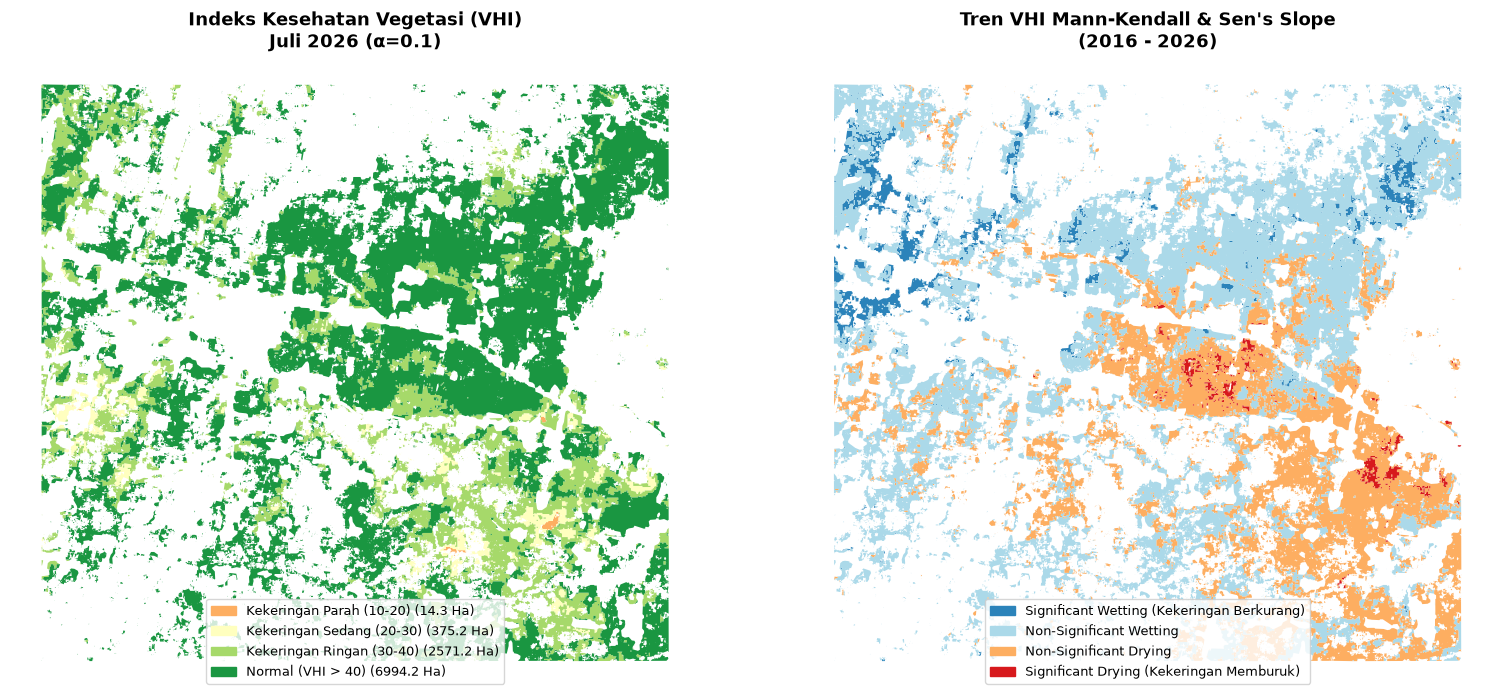


=== SEMUA PROSES DAN PRATINJAU SELESAI ===


In [6]:
"""
================================================================================
ANALISIS KEKERINGAN LAHAN SAWAH BERBASIS VHI & TREN SEN'S SLOPE (GEE)
REVISI: PERBAIKAN BUG "GeoJSON tren kosong" (masking piksel saat ekspor GEE)
================================================================================
AKAR MASALAH: "Tren_VHI_SensSlope_...: tidak ada fitur terpoligonisasi"

  trend_class_img dibangun sbg ee.Image(NODATA).byte() lalu di-.where() utk
  4 kelas, lalu di-.updateMask(trend_slope.mask()). MASALAHNYA: updateMask()
  hanya menandai piksel sbg transparan/tak-valid secara METADATA - TIDAK
  menjamin nilai piksel yg ditulis GEE ke GeoTIFF hasil ekspor tetap 255 (nilai
  konstanta dasarnya) di area yg ter-mask itu. Perilaku ekspor GEE utk piksel
  masked TIDAK dijamin konsisten (seringkali ditulis 0, bukan nilai
  dasar aslinya) - jadi asumsi kode lama "piksel invalid = 255" tdk valid,
  dan bisa membuat SELURUH array yg dibaca kembali tdk cocok dgn sentinel
  NODATA=255 yg dipakai filter poligonisasi, shg 0 fitur lolos.

PERBAIKAN: panggil `.unmask(NODATA)` di SISI SERVER (GEE) sblm diunduh -
  ini MENGHILANGKAN mask sepenuhnya & memaksa nilai piksel yg ditulis ke
  GeoTIFF benar-benar 255 di seluruh area yg tadinya invalid, TIDAK lagi
  bergantung pd perilaku implisit GEE saat mengekspor citra bermask. Fix yg
  sama diterapkan jg ke vhi_terbaru_img (pakai sentinel -1, krn VHI valid
  scr teoritis di rentang 0-100) - shg piksel tanpa data tdk keliru terbaca
  sbg VHI=0 ("Kekeringan Ekstrem") stlh diunduh. Ditambah print diagnostik
  jumlah piksel valid/invalid sblm poligonisasi, utk membantu jika ternyata
  akar masalahnya lain (mis. baseline VCI/TCI memang minim data valid).
================================================================================
"""

import os, warnings, datetime
import numpy as np
import geopandas as gpd
from shapely.geometry import box, shape as shapely_shape
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rioxarray
import xarray as xr
import ee
import requests
import rasterio
from rasterio.features import shapes as rio_shapes
from scipy.stats import pearsonr, fisk, norm

warnings.filterwarnings('ignore')

# ==============================================================================
# 1. KONFIGURASI PARAMETER
# ==============================================================================
PROJECT_ID = "poetic-emblem-487109-t6"  # Sesuaikan dengan Project ID Anda

RAW_DIR = "../../data/raw"
PROCESSED_DIR = "../../data/processed"
FIGURES_DIR = "../../results/figures/module_3"
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

FILE_SAWAH = os.path.join(PROCESSED_DIR, "Klasifikasi_Sawah.tif")
MODULE_DIR = os.path.join(PROCESSED_DIR, "module_3")
os.makedirs(MODULE_DIR, exist_ok=True)

TAHUN_AWAL_ANALISIS = 2016  # Disesuaikan dengan gambar rujukan (2016 - 2026)
TAHUN_AKHIR_ANALISIS = 2026
BULAN_ANALISIS = 7  # Juli (bulan tengah jendela musim kemarau)

# --- PERBAIKAN: baseline (hist_col) sblm ini sering menghasilkan 0 piksel tren
#     valid krn hanya 1 bulan (Juli) x cloud<40% x per tahun - kombinasi ini
#     bisa membuat ndvi_max==ndvi_min di hampir semua piksel (VCI/TCI masked
#     di SEMUA 11 tahun sekaligus -> sensSlope/kendallsCorrelation 0 titik
#     valid dimana-mana). Dua langkah mitigasi (TIDAK mengubah rentang tahun
#     analisis, sesuai saran pesan diagnostik):
#       1. JENDELA_BULAN: sertakan +/- 1 bulan di sekitar Juli (Jun-Ags) -
#          tetap mewakili "musim kemarau" yg sama scr musiman, tp lebih byk
#          kandidat citra per tahun.
#       2. CLOUD_TIERS_BASELINE: naikkan ambang tutupan awan scr bertahap
#          (pola sama spt modul fase tanam padi) sampai jumlah citra
#          baseline mencukupi (>= MIN_CITRA_BASELINE), baru berhenti.
JENDELA_BULAN = 1
CLOUD_TIERS_BASELINE = [40, 60, 80, 100]
MIN_CITRA_BASELINE = 15
BULAN_BAWAH = max(1, BULAN_ANALISIS - JENDELA_BULAN)
BULAN_ATAS = min(12, BULAN_ANALISIS + JENDELA_BULAN)

NODATA = 255
VHI_SENTINEL_INVALID = -1  # sentinel di luar rentang valid VHI (0-100), poin perbaikan
TOLERANSI_SIMPLIFY_M = 15

# --- Kelas VHI (Sesuai dengan gambar rujukan dan tabel pada jurnal) ---
KELAS_VHI = {
    1: "Kekeringan Ekstrem (VHI <= 10)",
    2: "Kekeringan Parah (10-20)",
    3: "Kekeringan Sedang (20-30)",
    4: "Kekeringan Ringan (30-40)",
    5: "Normal (VHI > 40)",
}
RENTANG_VHI = {1: "0 - 10", 2: "10 - 20", 3: "20 - 30", 4: "30 - 40", 5: "> 40"}
WARNA_VHI = {1: "#D7191C", 2: "#FDAE61", 3: "#FFFFBF", 4: "#A6D96A", 5: "#1A9641"}

# --- Kelas Tren Sen's Slope & Mann Kendall (4 kelas sesuai referensi dan gambar) ---
LABEL_TREND = {
    1: "Significant Wetting (Kekeringan Berkurang)",
    2: "Non-Significant Wetting",
    3: "Non-Significant Drying",
    4: "Significant Drying (Kekeringan Memburuk)"
}
RENTANG_TREND = {
    1: "slope > 0, p <= 0.05",
    2: "slope > 0, p > 0.05",
    3: "slope <= 0, p > 0.05",
    4: "slope <= 0, p <= 0.05"
}
WARNA_TREND = {1: "#2B83BA", 2: "#ABD9E9", 3: "#FDAE61", 4: "#D7191C"}

# ==============================================================================
# 2. INISIALISASI GEE & MASKING SAWAH
# ==============================================================================
print("=== TAHAP 1: Inisialisasi GEE & Membaca Masking Sawah ===")
try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

da_sawah = rioxarray.open_rasterio(FILE_SAWAH).squeeze(drop=True)
mask_sawah = (da_sawah.values == 1)
crs_epsg = da_sawah.rio.crs.to_epsg()
bounds_utm = da_sawah.rio.bounds()

gdf_bounds = gpd.GeoDataFrame(geometry=[box(*bounds_utm)], crs=f"EPSG:{crs_epsg}")
wgs_bounds = gdf_bounds.to_crs("EPSG:4326").total_bounds
aoi_ee = ee.Geometry.Rectangle([wgs_bounds[0], wgs_bounds[1], wgs_bounds[2], wgs_bounds[3]])

# ==============================================================================
# 3. FUNGSI GEE SERVER-SIDE (BASELINE MAX/MIN, 2016-2026)
# ==============================================================================
print(f"\n=== TAHAP 2: Menghitung Baseline Max/Min Historis (Juli {TAHUN_AWAL_ANALISIS}-{TAHUN_AKHIR_ANALISIS}) ===")

def mask_l89_clouds(image):
    qa = image.select('QA_PIXEL')
    dilated_cloud = 1 << 1
    cloud = 1 << 3
    cloud_shadow = 1 << 4
    mask = qa.bitwiseAnd(cloud).eq(0) \
             .And(qa.bitwiseAnd(cloud_shadow).eq(0)) \
             .And(qa.bitwiseAnd(dilated_cloud).eq(0))
    return image.updateMask(mask)

def add_indices(image):
    img_masked = mask_l89_clouds(image)
    opt = img_masked.select(['SR_B4', 'SR_B5']).multiply(0.0000275).add(-0.2)
    ndvi = opt.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
    lst = img_masked.select('ST_B10').multiply(0.00341802).add(149.0).subtract(273.15).rename('LST')
    return img_masked.addBands([ndvi, lst])

def bangun_koleksi_baseline(bulan_bawah, bulan_atas, cloud_tiers=CLOUD_TIERS_BASELINE, min_citra=MIN_CITRA_BASELINE):
    """Naikkan ambang awan bertahap sampai jumlah citra baseline >= target (poin perbaikan)."""
    gab, cmax, n = None, cloud_tiers[-1], 0
    for cmax in cloud_tiers:
        l8 = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterBounds(aoi_ee)
              .filter(ee.Filter.lt('CLOUD_COVER', cmax))
              .filter(ee.Filter.calendarRange(bulan_bawah, bulan_atas, 'month'))
              .filter(ee.Filter.calendarRange(TAHUN_AWAL_ANALISIS, TAHUN_AKHIR_ANALISIS, 'year'))
              .map(add_indices))
        l9 = (ee.ImageCollection("LANDSAT/LC09/C02/T1_L2").filterBounds(aoi_ee)
              .filter(ee.Filter.lt('CLOUD_COVER', cmax))
              .filter(ee.Filter.calendarRange(bulan_bawah, bulan_atas, 'month'))
              .filter(ee.Filter.calendarRange(max(TAHUN_AWAL_ANALISIS, 2021), TAHUN_AKHIR_ANALISIS, 'year'))
              .map(add_indices))
        gab = l8.merge(l9)
        n = gab.size().getInfo()
        print(f"   [Baseline] ambang awan <{cmax}%, bulan {bulan_bawah}-{bulan_atas}: {n} citra")
        if n >= min_citra:
            break
    return gab, cmax, n

hist_col, cloud_max_terpakai, n_hist_col = bangun_koleksi_baseline(BULAN_BAWAH, BULAN_ATAS)
if n_hist_col < MIN_CITRA_BASELINE:
    print(f"   [Peringatan] Hanya {n_hist_col} citra baseline (target minimal {MIN_CITRA_BASELINE}) "
          f"meski sudah di ambang paling longgar ({CLOUD_TIERS_BASELINE[-1]}%). Tren mungkin msh "
          "sparse - pertimbangkan memperlebar JENDELA_BULAN atau memeriksa ketersediaan citra "
          "Landsat 8/9 utk AOI ini scr manual di code editor GEE.")

print(f"-> Jumlah citra baseline terpakai (bulan {BULAN_BAWAH}-{BULAN_ATAS}, ambang awan <{cloud_max_terpakai}%, "
      f"{TAHUN_AWAL_ANALISIS}-{TAHUN_AKHIR_ANALISIS}): {n_hist_col}")

ndvi_max = hist_col.select('NDVI').max()
ndvi_min = hist_col.select('NDVI').min()
lst_max = hist_col.select('LST').max()
lst_min = hist_col.select('LST').min()

# ==============================================================================
# 3B. KOLEKSI LANDSAT BULANAN (SEMUA BULAN) KHUSUS UTK KALIBRASI ALPHA
# ==============================================================================
l8_bulanan = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterBounds(aoi_ee)
              .filter(ee.Filter.lt('CLOUD_COVER', 40))
              .filter(ee.Filter.calendarRange(TAHUN_AWAL_ANALISIS, TAHUN_AKHIR_ANALISIS, 'year'))
              .map(add_indices))
l9_bulanan = (ee.ImageCollection("LANDSAT/LC09/C02/T1_L2").filterBounds(aoi_ee)
              .filter(ee.Filter.lt('CLOUD_COVER', 40))
              .filter(ee.Filter.calendarRange(max(TAHUN_AWAL_ANALISIS, 2021), TAHUN_AKHIR_ANALISIS, 'year'))
              .map(add_indices))
hist_col_bulanan = l8_bulanan.merge(l9_bulanan)

ndvi_max_kal = hist_col_bulanan.select('NDVI').max()
ndvi_min_kal = hist_col_bulanan.select('NDVI').min()
lst_max_kal = hist_col_bulanan.select('LST').max()
lst_min_kal = hist_col_bulanan.select('LST').min()

# ==============================================================================
# 4. OPTIMASI NILAI ALPHA MENGGUNAKAN PROXY SPEI
# ==============================================================================
print("\n=== TAHAP 3: Optimasi Bobot Alpha (\u03B1) menggunakan Proxy SPEI ===")

chirps = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
modis_pet_col = ee.ImageCollection("MODIS/061/MOD16A2")

citra_chirps_terakhir = chirps.sort('system:time_start', False).first()
tgl_chirps_ms = ee.Date(citra_chirps_terakhir.get('system:time_start')).getInfo()['value']
citra_modis_terakhir = modis_pet_col.sort('system:time_start', False).first()
tgl_modis_ms = ee.Date(citra_modis_terakhir.get('system:time_start')).getInfo()['value']

tgl_chirps_terakhir = datetime.datetime.utcfromtimestamp(tgl_chirps_ms / 1000).date()
tgl_modis_terakhir = datetime.datetime.utcfromtimestamp(tgl_modis_ms / 1000).date()
batas_bulan_data = min(tgl_chirps_terakhir, tgl_modis_terakhir).replace(day=1)

kombinasi_tahun_bulan = []
for th in range(TAHUN_AWAL_ANALISIS, TAHUN_AKHIR_ANALISIS + 1):
    for bl in range(1, 13):
        if datetime.date(th, bl, 1) < batas_bulan_data:
            kombinasi_tahun_bulan.append([th, bl])

tahun_akhir_kalibrasi = max(pasangan[0] for pasangan in kombinasi_tahun_bulan)

def get_monthly_means(pasangan):
    pasangan = ee.List(pasangan)
    y = ee.Number(pasangan.get(0))
    m = ee.Number(pasangan.get(1))
    t_awal = ee.Date.fromYMD(y, m, 1)
    t_akhir = t_awal.advance(1, 'month')

    col_bulan = hist_col_bulanan.filterDate(t_awal, t_akhir)
    img = ee.Image(ee.Algorithms.If(
        col_bulan.size().gt(0),
        col_bulan.median(),
        ee.Image.constant([0, 0]).rename(['NDVI', 'LST']).updateMask(0)
    ))

    vci = img.select('NDVI').subtract(ndvi_min_kal).divide(ndvi_max_kal.subtract(ndvi_min_kal)).multiply(100)
    tci = lst_max_kal.subtract(img.select('LST')).divide(lst_max_kal.subtract(lst_min_kal)).multiply(100)

    c_col = chirps.filterDate(t_awal, t_akhir)
    pr_bulan = ee.Image(ee.Algorithms.If(
        c_col.size().gt(0),
        c_col.select('precipitation').sum(),
        ee.Image.constant(0).rename('precipitation').updateMask(0)
    )).rename('PR')

    m_col = modis_pet_col.filterDate(t_awal, t_akhir)
    pet_bulan = ee.Image(ee.Algorithms.If(
        m_col.size().gt(0),
        m_col.select('PET').sum().multiply(0.1),
        ee.Image.constant(0).rename('PET').updateMask(0)
    )).rename('PET')

    wb = pr_bulan.subtract(pet_bulan).rename('WB')

    means = ee.Image([vci.rename('VCI'), tci.rename('TCI'), wb]) \
              .reduceRegion(reducer=ee.Reducer.mean(), geometry=aoi_ee, scale=100, maxPixels=1e9)

    props = ee.Dictionary(ee.Algorithms.If(col_bulan.size().gt(0), means, ee.Dictionary({})))
    return ee.Feature(None, props).set({'year': y, 'month': m})

kombinasi_ee = ee.List(kombinasi_tahun_bulan)
ts_features = ee.FeatureCollection(kombinasi_ee.map(get_monthly_means)).getInfo()

vci_arr, tci_arr, wb_arr = [], [], []
for f in ts_features['features']:
    props = f['properties']
    if props.get('VCI') is not None and props.get('WB') is not None:
        vci_arr.append(props['VCI']); tci_arr.append(props['TCI']); wb_arr.append(props['WB'])

vci_arr, tci_arr, wb_arr = np.array(vci_arr), np.array(tci_arr), np.array(wb_arr)
print(f"-> {len(vci_arr)}/{len(kombinasi_tahun_bulan)} bulan kalibrasi punya data VCI/TCI/WB valid.")

try:
    par_fisk = fisk.fit(wb_arr)
    cdf_wb = fisk.cdf(wb_arr, *par_fisk)
    cdf_wb = np.clip(cdf_wb, 1e-6, 1 - 1e-6)
    spei_proxy_arr = norm.ppf(cdf_wb)
except Exception as e:
    spei_proxy_arr = (wb_arr - wb_arr.mean()) / wb_arr.std()

alpha_range = np.arange(0.0, 1.01, 0.05)
correlations = []
for a in alpha_range:
    vhi_test = (a * vci_arr) + ((1 - a) * tci_arr)
    corr, _ = pearsonr(vhi_test, spei_proxy_arr)
    correlations.append(corr)

best_alpha = alpha_range[np.argmax(correlations)]
print(f"-> Bobot Alpha optimal didapatkan: {best_alpha:.2f}")

# ==============================================================================
# 5. TREN VHI PER TAHUN - DIHITUNG LOKAL (numpy), BUKAN VIA ee.Reducer SERVER-SIDE
# ==============================================================================
print(f"\n=== TAHAP 4: Menghitung Tren VHI per Tahun ({TAHUN_AWAL_ANALISIS}-{TAHUN_AKHIR_ANALISIS}) ===")
# >> PERBAIKAN UTAMA (mengganti pendekatan sebelumnya): ee.Reducer.sensSlope()
#    & ee.Reducer.kendallsCorrelation() yg dijalankan server-side GEE atas
#    ImageCollection 11-tahun KONSISTEN menghasilkan 0 piksel tren valid di
#    SELURUH AOI - padahal VHI per-tahun dgn FORMULA IDENTIK terbukti 100%
#    valid saat diunduh satu-satu (img_terbaru, bukti empiris dr diagnostik
#    sebelumnya). Ini menunjukkan masalahnya ada pd reducer/agregasi 2-band
#    server-side itu sendiri (kemungkinan besar isu penamaan/tipe band
#    internal yg tdk tertelusuri dari sisi client, sulit di-debug krn
#    prosesnya "kotak hitam" di server) - BUKAN lagi soal kelangkaan data
#    (baseline sdh 147 citra, 6-8 avg/thn, jauh di atas cukup).
#
#    SOLUSI: unduh VHI TIAP TAHUN sbg raster terpisah (pola yg SUDAH
#    terbukti andal, identik dgn cara img_terbaru diunduh), lalu hitung
#    Sen's Slope & uji Mann-Kendall SENDIRI scr LOKAL dgn numpy. Fungsi di
#    bawah TERVEKTORISASI PENUH: loop HANYA atas 55 pasangan tahun (11
#    pilih 2), BUKAN per piksel - shg tetap cepat utk jutaan piksel, dan
#    hasilnya transparan/bisa diperiksa langsung (n_valid per piksel dicetak).
MIN_TAHUN_VALID_TREND = 4  # min jumlah tahun bernilai valid di suatu piksel spy tren dihitung

def unduh_vhi_tahun(tahun, scale=30):
    """Unduh median VHI utk 1 tahun (pola identik dgn img_terbaru) -> array numpy, NaN utk piksel invalid."""
    col = hist_col.filter(ee.Filter.calendarRange(tahun, tahun, 'year'))
    n_citra = col.size().getInfo()
    if n_citra == 0:
        return None, 0

    img = col.median()
    vci = img.select('NDVI').subtract(ndvi_min).divide(ndvi_max.subtract(ndvi_min)).multiply(100)
    tci = lst_max.subtract(img.select('LST')).divide(lst_max.subtract(lst_min)).multiply(100)
    vhi_img = vci.multiply(best_alpha).add(tci.multiply(1 - best_alpha)).rename('VHI') \
                 .unmask(VHI_SENTINEL_INVALID)

    url = vhi_img.getDownloadURL({'scale': scale, 'crs': f'EPSG:{crs_epsg}', 'region': aoi_ee, 'format': 'GEO_TIFF'})
    path_tif = f"temp_vhi_{tahun}.tif"
    with open(path_tif, "wb") as f:
        f.write(requests.get(url).content)

    da_raw = rioxarray.open_rasterio(path_tif)
    da = da_raw.rio.reproject_match(da_sawah)
    arr = da.values[0].astype(np.float32)
    arr = np.where(arr < 0, np.nan, arr)  # sentinel invalid -> NaN
    da_raw.close()
    da.close()
    os.remove(path_tif)
    return arr, n_citra


tahun_list = list(range(TAHUN_AWAL_ANALISIS, TAHUN_AKHIR_ANALISIS + 1))
stack_tahun = []
for th in tahun_list:
    arr_th, n_citra_th = unduh_vhi_tahun(th)
    if arr_th is None:
        print(f"   [Tahun {th}] 0 citra - tahun ini diskip (dianggap NaN di seluruh piksel).")
        arr_th = np.full(da_sawah.shape, np.nan, dtype=np.float32)
    else:
        n_valid_th = int(np.sum(~np.isnan(arr_th) & mask_sawah))
        print(f"   [Tahun {th}] {n_citra_th} citra -> {n_valid_th}/{int(np.sum(mask_sawah))} piksel sawah valid.")
    stack_tahun.append(arr_th)

stack_vhi_tahunan = np.stack(stack_tahun)                       # (n_tahun, H, W)
tahun_arr = np.array(tahun_list, dtype=np.float64)


def hitung_mk_dan_sen(stack, tahun, min_titik=MIN_TAHUN_VALID_TREND):
    """
    Sen's Slope (median dr semua slope pasangan) & uji Mann-Kendall
    (aproksimasi normal standar, S-statistic) - TERVEKTORISASI: loop hanya
    atas pasangan (i<j) [55 pasangan utk 11 tahun], seluruh piksel dihitung
    sekaligus per pasangan lewat operasi array numpy biasa.
    """
    n_tahun = stack.shape[0]
    n_valid = np.sum(~np.isnan(stack), axis=0)

    daftar_sign, daftar_slope = [], []
    for i in range(n_tahun):
        for j in range(i + 1, n_tahun):
            beda_y = stack[j] - stack[i]
            beda_x = tahun[j] - tahun[i]
            pasangan_valid = ~np.isnan(beda_y)
            daftar_sign.append(np.where(pasangan_valid, np.sign(beda_y), np.nan))
            daftar_slope.append(np.where(pasangan_valid, beda_y / beda_x, np.nan))

    S = np.nansum(np.stack(daftar_sign), axis=0)
    sen_slope = np.nanmedian(np.stack(daftar_slope), axis=0)

    # Varians standar uji Mann-Kendall (aproksimasi tanpa koreksi ties, umum
    # dipakai dlm literatur tren remote sensing spt ini)
    varS = (n_valid * (n_valid - 1) * (2 * n_valid + 5)) / 18.0
    with np.errstate(invalid="ignore", divide="ignore"):
        z = np.where(S > 0, (S - 1) / np.sqrt(varS),
             np.where(S < 0, (S + 1) / np.sqrt(varS), 0.0))
    p_value = 2 * (1 - norm.cdf(np.abs(z)))

    tdk_cukup_data = n_valid < min_titik
    sen_slope = np.where(tdk_cukup_data, np.nan, sen_slope)
    p_value = np.where(tdk_cukup_data, np.nan, p_value)
    return sen_slope, p_value, n_valid


sen_slope, p_value, n_valid_tren = hitung_mk_dan_sen(stack_vhi_tahunan, tahun_arr)
print(f"   [Diagnostik] Rata-rata jumlah tahun valid per piksel sawah: "
      f"{np.nanmean(n_valid_tren[mask_sawah]):.1f} / {len(tahun_list)} "
      f"(min {MIN_TAHUN_VALID_TREND} dibutuhkan spy tren dihitung).")

trend_class = np.full(sen_slope.shape, np.nan)
valid_trend = mask_sawah & ~np.isnan(sen_slope) & ~np.isnan(p_value)
trend_class[valid_trend & (sen_slope > 0) & (p_value <= 0.05)] = 1
trend_class[valid_trend & (sen_slope > 0) & (p_value > 0.05)] = 2
trend_class[valid_trend & (sen_slope <= 0) & (p_value > 0.05)] = 3
trend_class[valid_trend & (sen_slope <= 0) & (p_value <= 0.05)] = 4
print(f"   [Diagnostik] Tren VHI: {int(np.sum(~np.isnan(trend_class)))}/{int(np.sum(mask_sawah))} "
      f"piksel sawah punya nilai tren valid.")
if np.sum(~np.isnan(trend_class)) == 0:
    print("   [Peringatan] Masih 0 piksel tren valid - cek baris [Tahun ...] di atas: jika sebagian "
          f"besar tahun benar2 0 citra, naikkan MIN_TAHUN_VALID_TREND turun atau perlebar JENDELA_BULAN.")

print(f"Menarik citra VHI terbaru Juli {TAHUN_AKHIR_ANALISIS}...")
img_terbaru = hist_col.filter(ee.Filter.calendarRange(TAHUN_AKHIR_ANALISIS, TAHUN_AKHIR_ANALISIS, 'year')).median()
vci_terbaru = img_terbaru.select('NDVI').subtract(ndvi_min).divide(ndvi_max.subtract(ndvi_min)).multiply(100)
tci_terbaru = lst_max.subtract(img_terbaru.select('LST')).divide(lst_max.subtract(lst_min)).multiply(100)

# >> Fix simetris (dipertahankan dr revisi sebelumnya): .unmask(VHI_SENTINEL_INVALID)
#    sblm diunduh, agar piksel tanpa data tdk keliru terbaca sbg VHI=0.
vhi_terbaru_img = vci_terbaru.multiply(best_alpha).add(tci_terbaru.multiply(1 - best_alpha)).rename('VHI') \
    .unmask(VHI_SENTINEL_INVALID)

url_terbaru = vhi_terbaru_img.getDownloadURL({'scale': 30, 'crs': f'EPSG:{crs_epsg}', 'region': aoi_ee, 'format': 'GEO_TIFF'})
with open("temp_vhi_terbaru.tif", "wb") as f:
    f.write(requests.get(url_terbaru).content)

# ==============================================================================
# 6. KLASIFIKASI KEKERINGAN LOKAL (VHI terbaru)
# ==============================================================================
print("\n=== TAHAP 5: Penyelarasan Masking Lahan Sawah (VHI terbaru) ===")
da_vhi_raw = rioxarray.open_rasterio("temp_vhi_terbaru.tif")
da_vhi = da_vhi_raw.rio.reproject_match(da_sawah)
vhi_arr = np.where(mask_sawah, da_vhi.values[0], np.nan)
vhi_arr = np.where(vhi_arr < 0, np.nan, vhi_arr)
print(f"   [Diagnostik] VHI: {int(np.sum(~np.isnan(vhi_arr)))}/{int(np.sum(mask_sawah))} piksel sawah punya nilai valid.")

kelas_arr = np.full(vhi_arr.shape, np.nan)
kelas_arr[(vhi_arr >= 0) & (vhi_arr <= 10)] = 1
kelas_arr[(vhi_arr > 10) & (vhi_arr <= 20)] = 2
kelas_arr[(vhi_arr > 20) & (vhi_arr <= 30)] = 3
kelas_arr[(vhi_arr > 30) & (vhi_arr <= 40)] = 4
kelas_arr[(vhi_arr > 40)] = 5

da_vhi_raw.close()
da_vhi.close()
if os.path.exists("temp_vhi_terbaru.tif"):
    os.remove("temp_vhi_terbaru.tif")

# ==============================================================================
# 7. POLIGONISASI + DISSOLVE PER KELAS + EKSPOR GEOJSON
# ==============================================================================
print("\n=== TAHAP 6: Poligonisasi & Ekspor GeoJSON ===")

def poligonisasi_kelas_ke_geojson(kelas_arr_in, transform, crs, dict_label, dict_rentang,
                                   nama_layer, path_out, toleransi_simplify_m=TOLERANSI_SIMPLIFY_M):
    kelas_u8 = np.where(np.isnan(kelas_arr_in), NODATA, kelas_arr_in).astype(np.uint8)

    records = [
        {"kelas": int(val), "geometry": shapely_shape(geom)}
        for geom, val in rio_shapes(kelas_u8, mask=(kelas_u8 != NODATA), transform=transform, connectivity=4)
    ]
    if not records:
        print(f"   [Peringatan] {nama_layer}: tidak ada fitur terpoligonisasi, GeoJSON dilewati.")
        return None

    gdf = gpd.GeoDataFrame(records, crs=crs)
    gdf = gdf.dissolve(by="kelas", as_index=False)

    if toleransi_simplify_m and toleransi_simplify_m > 0:
        gdf["geometry"] = gdf["geometry"].simplify(toleransi_simplify_m, preserve_topology=True)

    gdf["luas_ha"] = (gdf.geometry.area / 10000).round(2)
    gdf["label"] = gdf["kelas"].map(dict_label)
    gdf["rentang_nilai"] = gdf["kelas"].map(dict_rentang)
    gdf["indeks"] = nama_layer

    gdf = gdf.to_crs("EPSG:4326")
    gdf.to_file(path_out, driver="GeoJSON")

    ukuran_kb = os.path.getsize(path_out) / 1024
    print(f"   -> {nama_layer}: GeoJSON tersimpan ({len(gdf)} fitur kelas, {ukuran_kb:,.0f} KB)")
    return gdf

path_geojson_vhi = os.path.join(MODULE_DIR, f"Peta_VHI_Juli{TAHUN_AKHIR_ANALISIS}.geojson")
gdf_vhi = poligonisasi_kelas_ke_geojson(
    kelas_arr, da_sawah.rio.transform(), da_sawah.rio.crs,
    KELAS_VHI, RENTANG_VHI, f"VHI_Juli{TAHUN_AKHIR_ANALISIS}", path_geojson_vhi
)

path_geojson_trend = os.path.join(MODULE_DIR, f"Peta_Trend_SensSlope_VHI_{TAHUN_AWAL_ANALISIS}-{TAHUN_AKHIR_ANALISIS}.geojson")
gdf_trend = poligonisasi_kelas_ke_geojson(
    trend_class, da_sawah.rio.transform(), da_sawah.rio.crs,
    LABEL_TREND, RENTANG_TREND, f"Tren_VHI_SensSlope_{TAHUN_AWAL_ANALISIS}-{TAHUN_AKHIR_ANALISIS}", path_geojson_trend
)

for f in [f"temp_vhi_{th}.tif" for th in tahun_list] + ["temp_vhi_terbaru.tif"]:
    if os.path.exists(f): os.remove(f)

# ==============================================================================
# 8. PRATINJAU HASIL DI AKHIR UNTUK REVIEW MENYERUPAI GAMBAR RUJUKAN
# ==============================================================================
print("\n=== TAHAP 7: Pratinjau Hasil ===")

# --- Menghitung luasan per kelas untuk diletakkan di Legenda VHI ---
luas_vhi = {}
if gdf_vhi is not None:
    for k in KELAS_VHI.keys():
        if k in gdf_vhi["kelas"].values:
            luas_vhi[k] = gdf_vhi.loc[gdf_vhi["kelas"] == k, "luas_ha"].sum()
        else:
            luas_vhi[k] = 0

# --- Ploting Side-by-Side menyerupai gambar rujukan ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Map 1: VHI Juli
if gdf_vhi is not None:
    for k in KELAS_VHI.keys():
        if k in gdf_vhi["kelas"].values:
            gdf_vhi[gdf_vhi["kelas"] == k].plot(ax=axes[0], color=WARNA_VHI[k], edgecolor="none")
    handles_vhi = [mpatches.Patch(color=WARNA_VHI[k], label=f"{KELAS_VHI[k]} ({luas_vhi[k]:.1f} Ha)")
                   for k in KELAS_VHI.keys() if luas_vhi[k] > 0]
    axes[0].legend(handles=handles_vhi, loc="lower center", fontsize=9)
    axes[0].set_title(f"Indeks Kesehatan Vegetasi (VHI)\nJuli {TAHUN_AKHIR_ANALISIS} (α={best_alpha:.1f})", fontsize=13, fontweight='bold')
else:
    axes[0].text(0.5, 0.5, "GeoJSON VHI tidak tersedia", ha="center", va="center")
axes[0].set_axis_off()

# Map 2: Trend VHI Mann-Kendall & Sen's Slope
if gdf_trend is not None:
    for k in LABEL_TREND.keys():
        if k in gdf_trend["kelas"].values:
            gdf_trend[gdf_trend["kelas"] == k].plot(ax=axes[1], color=WARNA_TREND[k], edgecolor="none")
    handles_trend = [mpatches.Patch(color=WARNA_TREND[k], label=LABEL_TREND[k]) for k in LABEL_TREND.keys()]
    axes[1].legend(handles=handles_trend, loc="lower center", fontsize=9)
    axes[1].set_title(f"Tren VHI Mann-Kendall & Sen's Slope\n({TAHUN_AWAL_ANALISIS} - {TAHUN_AKHIR_ANALISIS})", fontsize=13, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, "GeoJSON tren tidak tersedia\n(lihat log [Diagnostik]/[Peringatan] di atas)",
                  ha="center", va="center")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

print("\n=== SEMUA PROSES DAN PRATINJAU SELESAI ===")